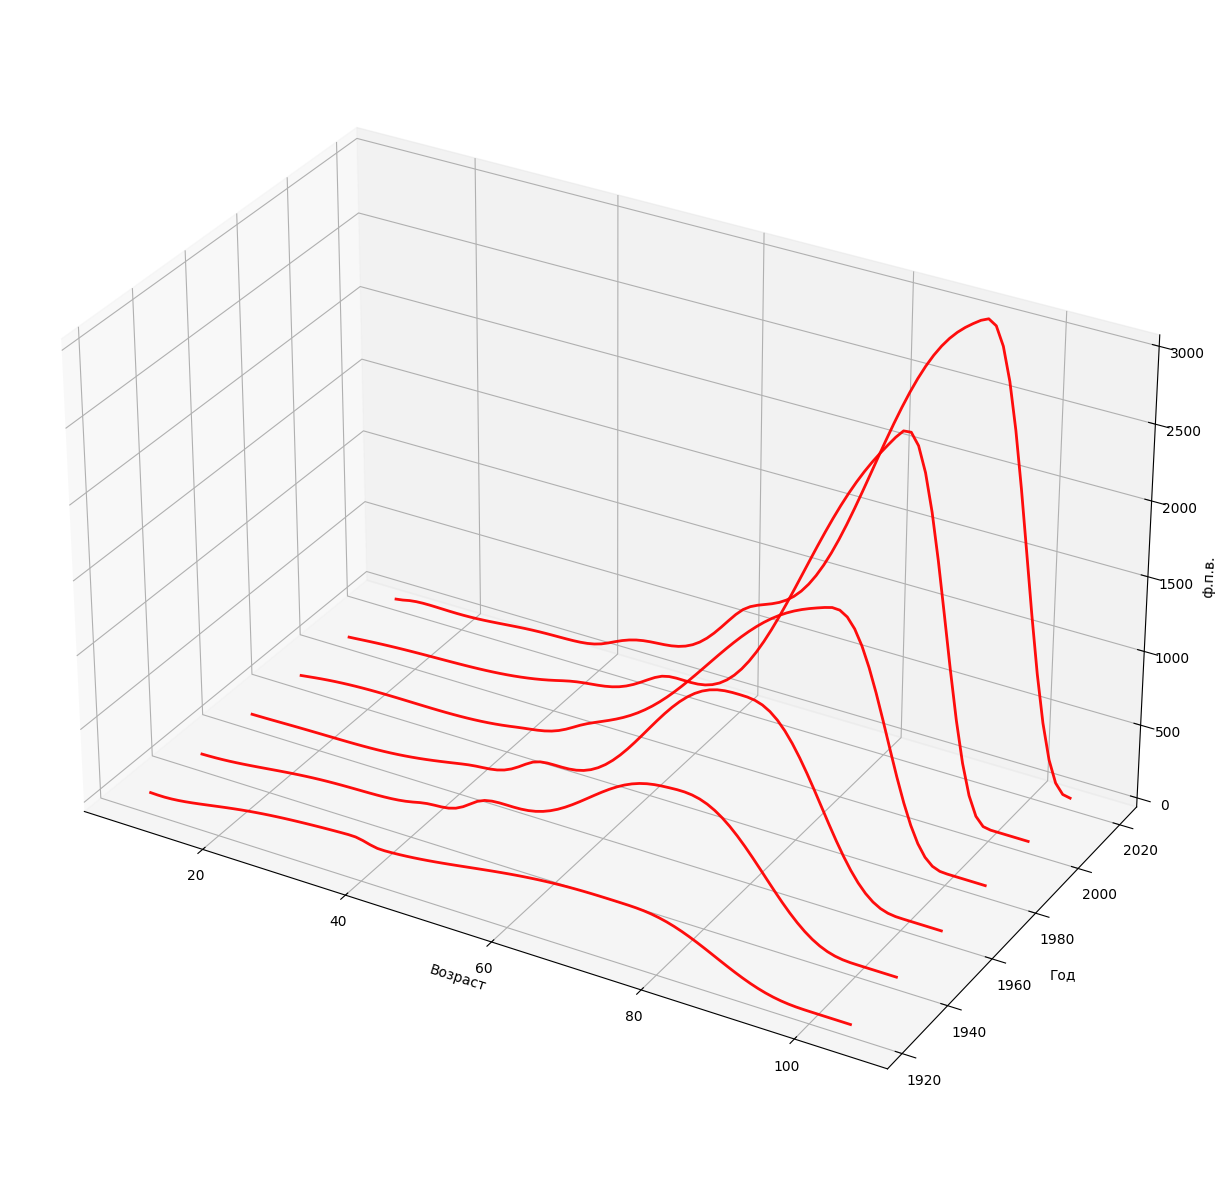

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Загрузка данных ---
# Загрузка красных данных (индивидуальные по годам)
df_red_raw = pd.read_csv('approximated_australia_deaths.txt', sep=r'\s+', header=None, names=['age', 'death_rate', 'year'])
df_red_raw['year'] = df_red_raw['year'].astype(int)
df_red_raw['age'] = df_red_raw['age'].astype(int)

# Полный диапазон возрастов
age_full = np.arange(10, 106)  # 10, 11 ... 105

# Список для полных данных
rows = []

# Для каждого года от 1921 до 2021 каждые 20 лет
for yr in range(1921, 2022, 20):
    # Выбираем данные для этого года
    year_data = df_red_raw[df_red_raw['year'] == yr]
    # Создаём Series: возраст-> уровень смертности
    dens_dict = dict(zip(year_data['age'], year_data['death_rate']))
    # Добавляем все возраста из полного диапазона
    for t in age_full:
        dens = dens_dict.get(t, 0.0)  # если нет — 0.0
        rows.append({'age': t, 'year': yr, 'death_rate': dens})

# Создаём новый DataFrame с полными данными
df_red = pd.DataFrame(rows)

# # Синие линии — одинаковые для всех лет
# df_blue = pd.read_csv('3Dsfp_01.txt', sep=r'\s+', header=None, names=['temperature', 'year', 'density'])
# # Берём данные для одного года (например, year=1) — они одинаковы для всех
# blue_curve = df_blue[df_blue['year'] == 1][['temperature', 'density']].sort_values('temperature')
# age_blue = blue_curve['temperature'].values
# dens_blue = blue_curve['density'].values

# Уникальные годы (1–13)
years = np.arange(1921, 2022, 20)

# --- Построение графика ---
fig = plt.figure(figsize=(12, 14))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1.7, 1, 1])  # [X, Y, Z] — относительные пропорции

# Синие линии — одинаковая кривая для каждого года
#for yr in years:
#    ax.plot(age_blue, [yr] * len(age_blue), dens_blue, color='blue', linewidth=1.2, alpha=0.7)

# # Синие линии со смещением: Y = 1.5, 2.5, ..., 12.5
# for i in range(12):  # 0..11 → 12 линий
#     y_pos = 1.5 + i  # 1.5, 2.5, ..., 12.5
#     ax.plot(age_all, [y_pos] * len(age_all), dens_all,
#             color='blue', linewidth=0.8, alpha=0.6)

# Красные линии — индивидуальные данные по годам
for yr in years:
    year_data = df_red[df_red['year'] == yr].sort_values('age')
    age_red = year_data['age'].values
    dens_red = year_data['death_rate'].values
    ax.plot(age_red, [yr] * len(age_red), dens_red, color='red', linewidth=2, alpha=0.95)

# Оформление
ax.set_xlabel('Возраст')
ax.set_ylabel('Год')
ax.set_zlabel('ф.п.в.')
#ax.set_title('Временной ряд распределений')


# # --- Синяя поверхность (однотонная, полупрозрачная) ---
# # Берём уникальные температуры и соответствующие плотности (они одинаковы для всех лет)
# blue_ref = df_blue[df_blue['year'] == 1].sort_values('temperature')
# age_all = blue_ref['temperature'].values
# dens_all = blue_ref['density'].values

# # Создаём сетку: X — температура, Y — года, Z — повторённая плотность для каждого года
# Y_blue = np.arange(1, 14)  # года 1–13
# X_surf, Y_surf = np.meshgrid(age_all, Y_blue)
# Z_surf = np.tile(dens_all, (len(Y_blue), 1))  # копируем строку плотности для каждого года

# # Строим поверхность
# ax.plot_surface(
#     X_surf, Y_surf, Z_surf,
#     color='blue',          # однотонный синий
#     alpha=0.2,             # полупрозрачность
#     linewidth=0,
#     edgecolor='none',
#     shade=False            # отключаем тени, чтобы цвет был равномерным
# )


# # --- Добавление линий каждые 5 градусов (параллельно оси Y) ---
# # Получаем синюю кривую (один раз, для года 1 — все одинаковые)
# blue_ref = df_blue[df_blue['year'] == 1].set_index('temperature')['density']

# # Температуры каждые 5 градусов в диапазоне данных
# temp_ticks = np.arange(-35, 41, 1)  # от -35 до 40 включительно

# # Годы
# years = np.arange(1, 14)

# for t in temp_ticks:
#     if t in blue_ref.index:
#         z_val = blue_ref[t]
#         # Линия: X = t, Y = [1..13], Z = z_val
#         ax.plot([t] * len(years), years, [z_val] * len(years),
#                 color='blue', linewidth=0.8, alpha=0.6)


# Убираем сетку для чистоты (опционально)
#ax.grid(False)
# plt.savefig('temperature_kde_3d.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()